# Student Performance


## Setup


In [1]:
# import libraries
import seaborn as sns
from sklearn.feature_selection import RFE, VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [2]:
import os
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)


%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc("axes", labelsize=14)
mpl.rc("xtick", labelsize=12)
mpl.rc("ytick", labelsize=12)

PROJECT_ROOT_DIR = "."
PROJECT_NAME = "stud_perform"
IMG_PATH = os.path.join(PROJECT_ROOT_DIR, "images", PROJECT_NAME)
os.makedirs(IMG_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMG_PATH, fig_id + "."+ fig_extension)
    if tight_layout:
        plt.tight_layout()
    print("Saving figure", fig_id)
    plt.savefig(path, format=fig_extension, dpi=resolution)

## Get the data


In [3]:
DATASET_PATH = os.path.join(PROJECT_ROOT_DIR, "Datasets", "student-mat.csv")

stud_perform = pd.read_csv(DATASET_PATH, sep=";")

#### Student Performance Dataset

##### Context

The data were obtained from a survey of students taking **Mathematics** and **Portuguese language courses** in secondary school.  
The dataset contains extensive **social, demographic, and academic information** about students.

It can be used for:

- **Exploratory Data Analysis (EDA)**
- **Predicting students' final grades**

---

#### Dataset Content

The following attributes exist in both datasets:

- **student-mat.csv** (Mathematics course)
- **student-por.csv** (Portuguese language course)

_We have chosen the student-mat.csv_

---

##### Student Information

**school**  
Student's school

- `GP` — Gabriel Pereira
- `MS` — Mousinho da Silveira

**sex**  
Student's gender

- `F` — Female
- `M` — Male

**age**  
Student's age

- Numeric: **15 to 22**

**address**  
Student's home address type

- `U` — Urban
- `R` — Rural

**famsize**  
Family size

- `LE3` — Less than or equal to 3
- `GT3` — Greater than 3

**Pstatus**  
Parent's cohabitation status

- `T` — Living together
- `A` — Apart

---

##### Parent Education

**Medu** — Mother's education

- `0` — None
- `1` — Primary education (4th grade)
- `2` — 5th to 9th grade
- `3` — Secondary education
- `4` — Higher education

**Fedu** — Father's education

- `0` — None
- `1` — Primary education (4th grade)
- `2` — 5th to 9th grade
- `3` — Secondary education
- `4` — Higher education

---

##### Parent Jobs

**Mjob** — Mother's job

- `teacher`
- `health` (healthcare related)
- `services` (administrative or police)
- `at_home`
- `other`

**Fjob** — Father's job

- `teacher`
- `health`
- `services`
- `at_home`
- `other`

---

##### School Choice

**reason** — Reason to choose the school

- `home`
- `reputation`
- `course`
- `other`

**guardian** — Student's guardian

- `mother`
- `father`
- `other`

---

##### Study Related Attributes

**traveltime** — Travel time from home to school

- `1` — < 15 minutes
- `2` — 15 to 30 minutes
- `3` — 30 minutes to 1 hour
- `4` — > 1 hour

**studytime** — Weekly study time

- `1` — < 2 hours
- `2` — 2 to 5 hours
- `3` — 5 to 10 hours
- `4` — > 10 hours

**failures** — Number of past class failures

- Numeric: `n` if `1 ≤ n < 3`, otherwise `4`

---

##### Academic Support

Binary values (`yes` or `no`)

- **schoolsup** — Extra educational support
- **famsup** — Family educational support
- **paid** — Extra paid classes within the course subject
- **activities** — Extra-curricular activities
- **nursery** — Attended nursery school
- **higher** — Wants to take higher education
- **internet** — Internet access at home
- **romantic** — In a romantic relationship

---

##### Social and Lifestyle Factors

**famrel** — Quality of family relationships

- `1` — Very bad
- `5` — Excellent

**freetime** — Free time after school

- `1` — Very low
- `5` — Very high

**goout** — Going out with friends

- `1` — Very low
- `5` — Very high

**Dalc** — Workday alcohol consumption

- `1` — Very low
- `5` — Very high

**Walc** — Weekend alcohol consumption

- `1` — Very low
- `5` — Very high

**health** — Current health status

- `1` — Very bad
- `5` — Very good

---

##### Attendance

**absences**  
Number of school absences

- Numeric: **0 to 93**

---

#### Grades

Grades are related to the course subject (**Math or Portuguese**).

**G1** — First period grade

- Numeric: **0 to 20**

**G2** — Second period grade

- Numeric: **0 to 20**

**G3** — Final grade (**Target Variable**)

- Numeric: **0 to 20**

---

##### Additional Note

There are **382 students** that appear in **both datasets**.  
These students can be identified by searching for identical attributes that characterize each student.

This matching process is demonstrated in the **annexed R file** provided with the dataset.

---

#### Source Information

**Paper**

P. Cortez and A. Silva  
_Using Data Mining to Predict Secondary School Student Performance._

In:
_A. Brito and J. Teixeira (Eds.), Proceedings of the 5th Future Business Technology Conference (FUBUTEC 2008)_  
Porto, Portugal, April 2008  
EUROSIS  
ISBN: **978-9077381-39-7**

---

#### Contributors

Fabio Pagnotta  
Hossain Mohammad Amran

Emails:

- fabio.pagnotta@studenti.unicam.it
- mohammadamra.hossain@studenti.unicam.it

University of Camerino

---

#### Dataset Link

https://archive.ics.uci.edu/ml/datasets/STUDENT+ALCOHOL+CONSUMPTION


### Take quick look at the Datastructure


In [4]:
stud_perform.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [5]:
stud_perform.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [6]:
cat_columns = stud_perform.select_dtypes(exclude=["number"])
for column in cat_columns:
    print(f"Column : {stud_perform[column].value_counts()}")
    print("=" * 40)

Column : school
GP    349
MS     46
Name: count, dtype: int64
Column : sex
F    208
M    187
Name: count, dtype: int64
Column : address
U    307
R     88
Name: count, dtype: int64
Column : famsize
GT3    281
LE3    114
Name: count, dtype: int64
Column : Pstatus
T    354
A     41
Name: count, dtype: int64
Column : Mjob
other       141
services    103
at_home      59
teacher      58
health       34
Name: count, dtype: int64
Column : Fjob
other       217
services    111
teacher      29
at_home      20
health       18
Name: count, dtype: int64
Column : reason
course        145
home          109
reputation    105
other          36
Name: count, dtype: int64
Column : guardian
mother    273
father     90
other      32
Name: count, dtype: int64
Column : schoolsup
no     344
yes     51
Name: count, dtype: int64
Column : famsup
yes    242
no     153
Name: count, dtype: int64
Column : paid
no     214
yes    181
Name: count, dtype: int64
Column : activities
yes    201
no     194
Name: count, dtype:

Saving figure cat_dat_distribution


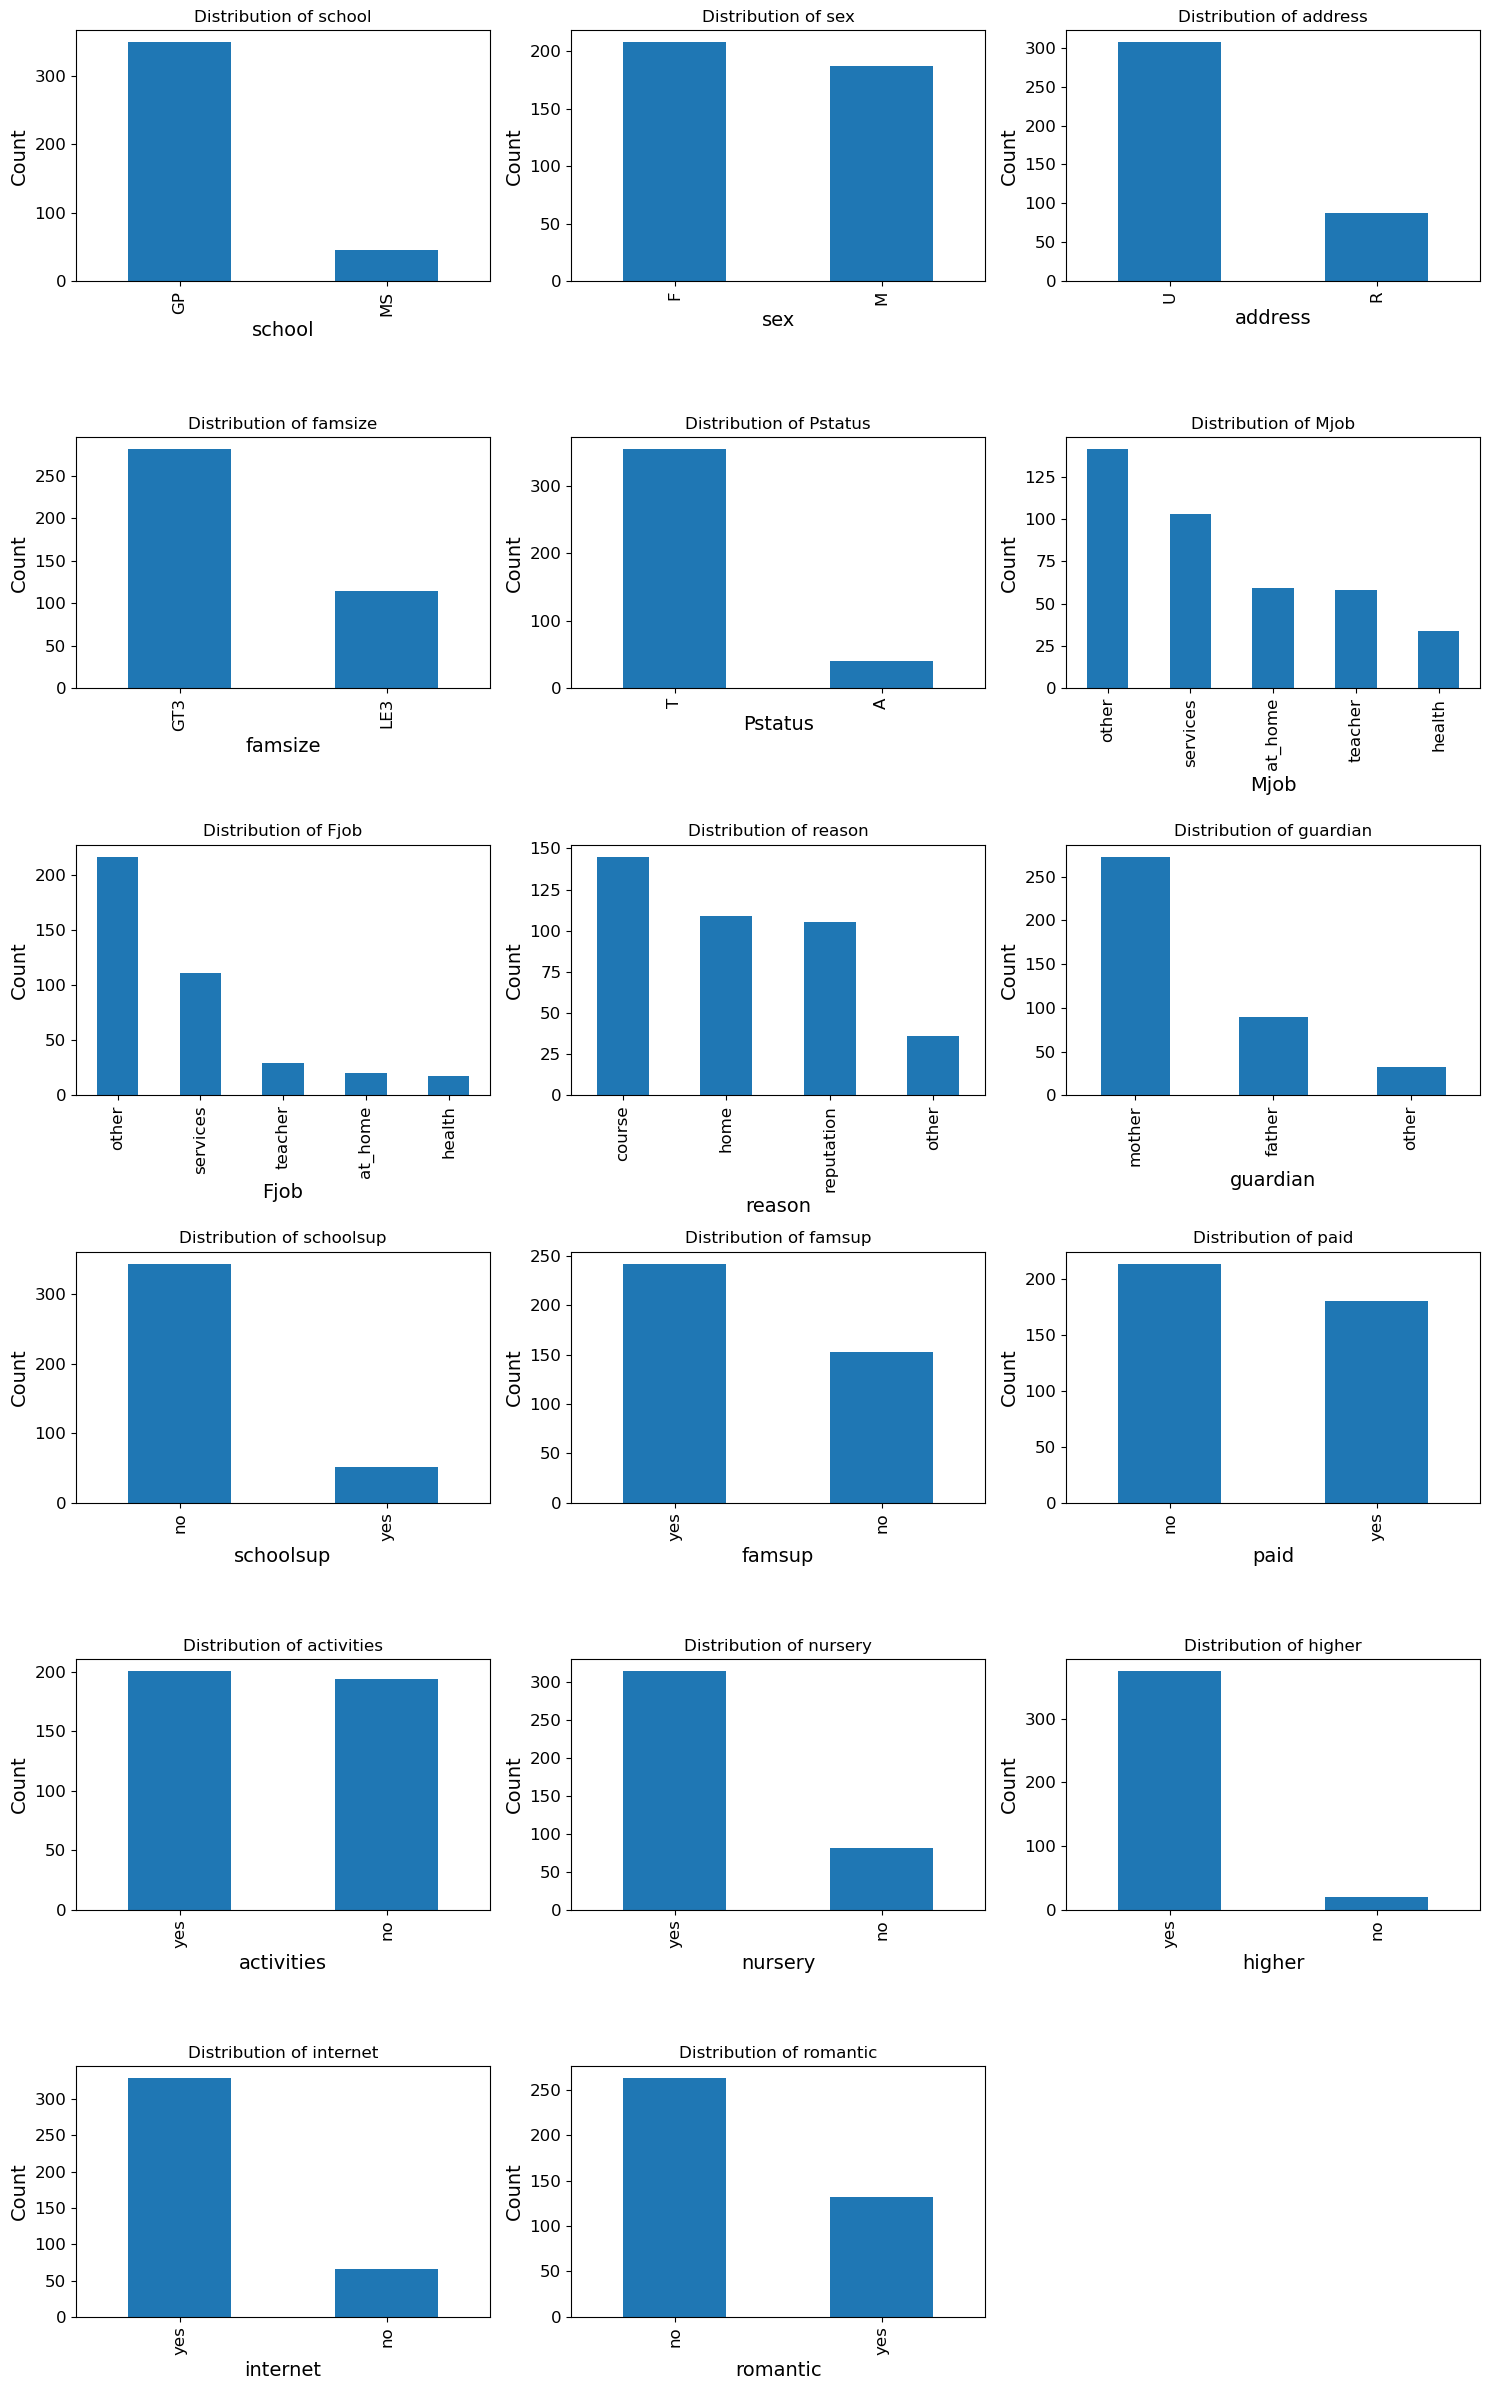

In [7]:
import matplotlib.pyplot as plt
import math

cat_columns = stud_perform.select_dtypes(exclude=["number"])

n_cols = 3  # number of plots per row
n_rows = math.ceil(len(cat_columns.columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_columns.columns):
    stud_perform[col].value_counts().plot(kind="bar", ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

# Remove empty plots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
save_fig("cat_dat_distribution")
plt.show()

#### Key Insights from the Dataset

##### Dataset Overview

The dataset contains **395 student records** with **33 features**, including **16 numerical** and **17 categorical variables** describing demographic, academic, and lifestyle factors.

---

##### School Distribution

Most students belong to **Gabriel Pereira (GP)**.

- GP: 349 (~88%)
- MS: 46 (~12%)

This indicates the dataset is **imbalanced toward one school**.

---

##### Gender Distribution

The dataset is **fairly balanced**.

- Female: 208 (~53%)
- Male: 187 (~47%)

---

##### Urban vs Rural

Most students live in **urban areas**.

- Urban: 307 (~78%)
- Rural: 88 (~22%)

This indicate there is a chance that this dataset was collected from urban schools

---

##### Educational Support

Family support is common, while **school support is limited**.

- School support: 51
- Family support: 242

---

##### Internet Access

Most students have **internet access at home**.

- Yes: 329
- No: 66

---


In [8]:
stud_perform.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


Students have an average of **5.7 absences**, but the maximum value is **75**, which suggests the presence of **extreme outliers** with unusually high absence counts.


Saving figure num_dat_distribution


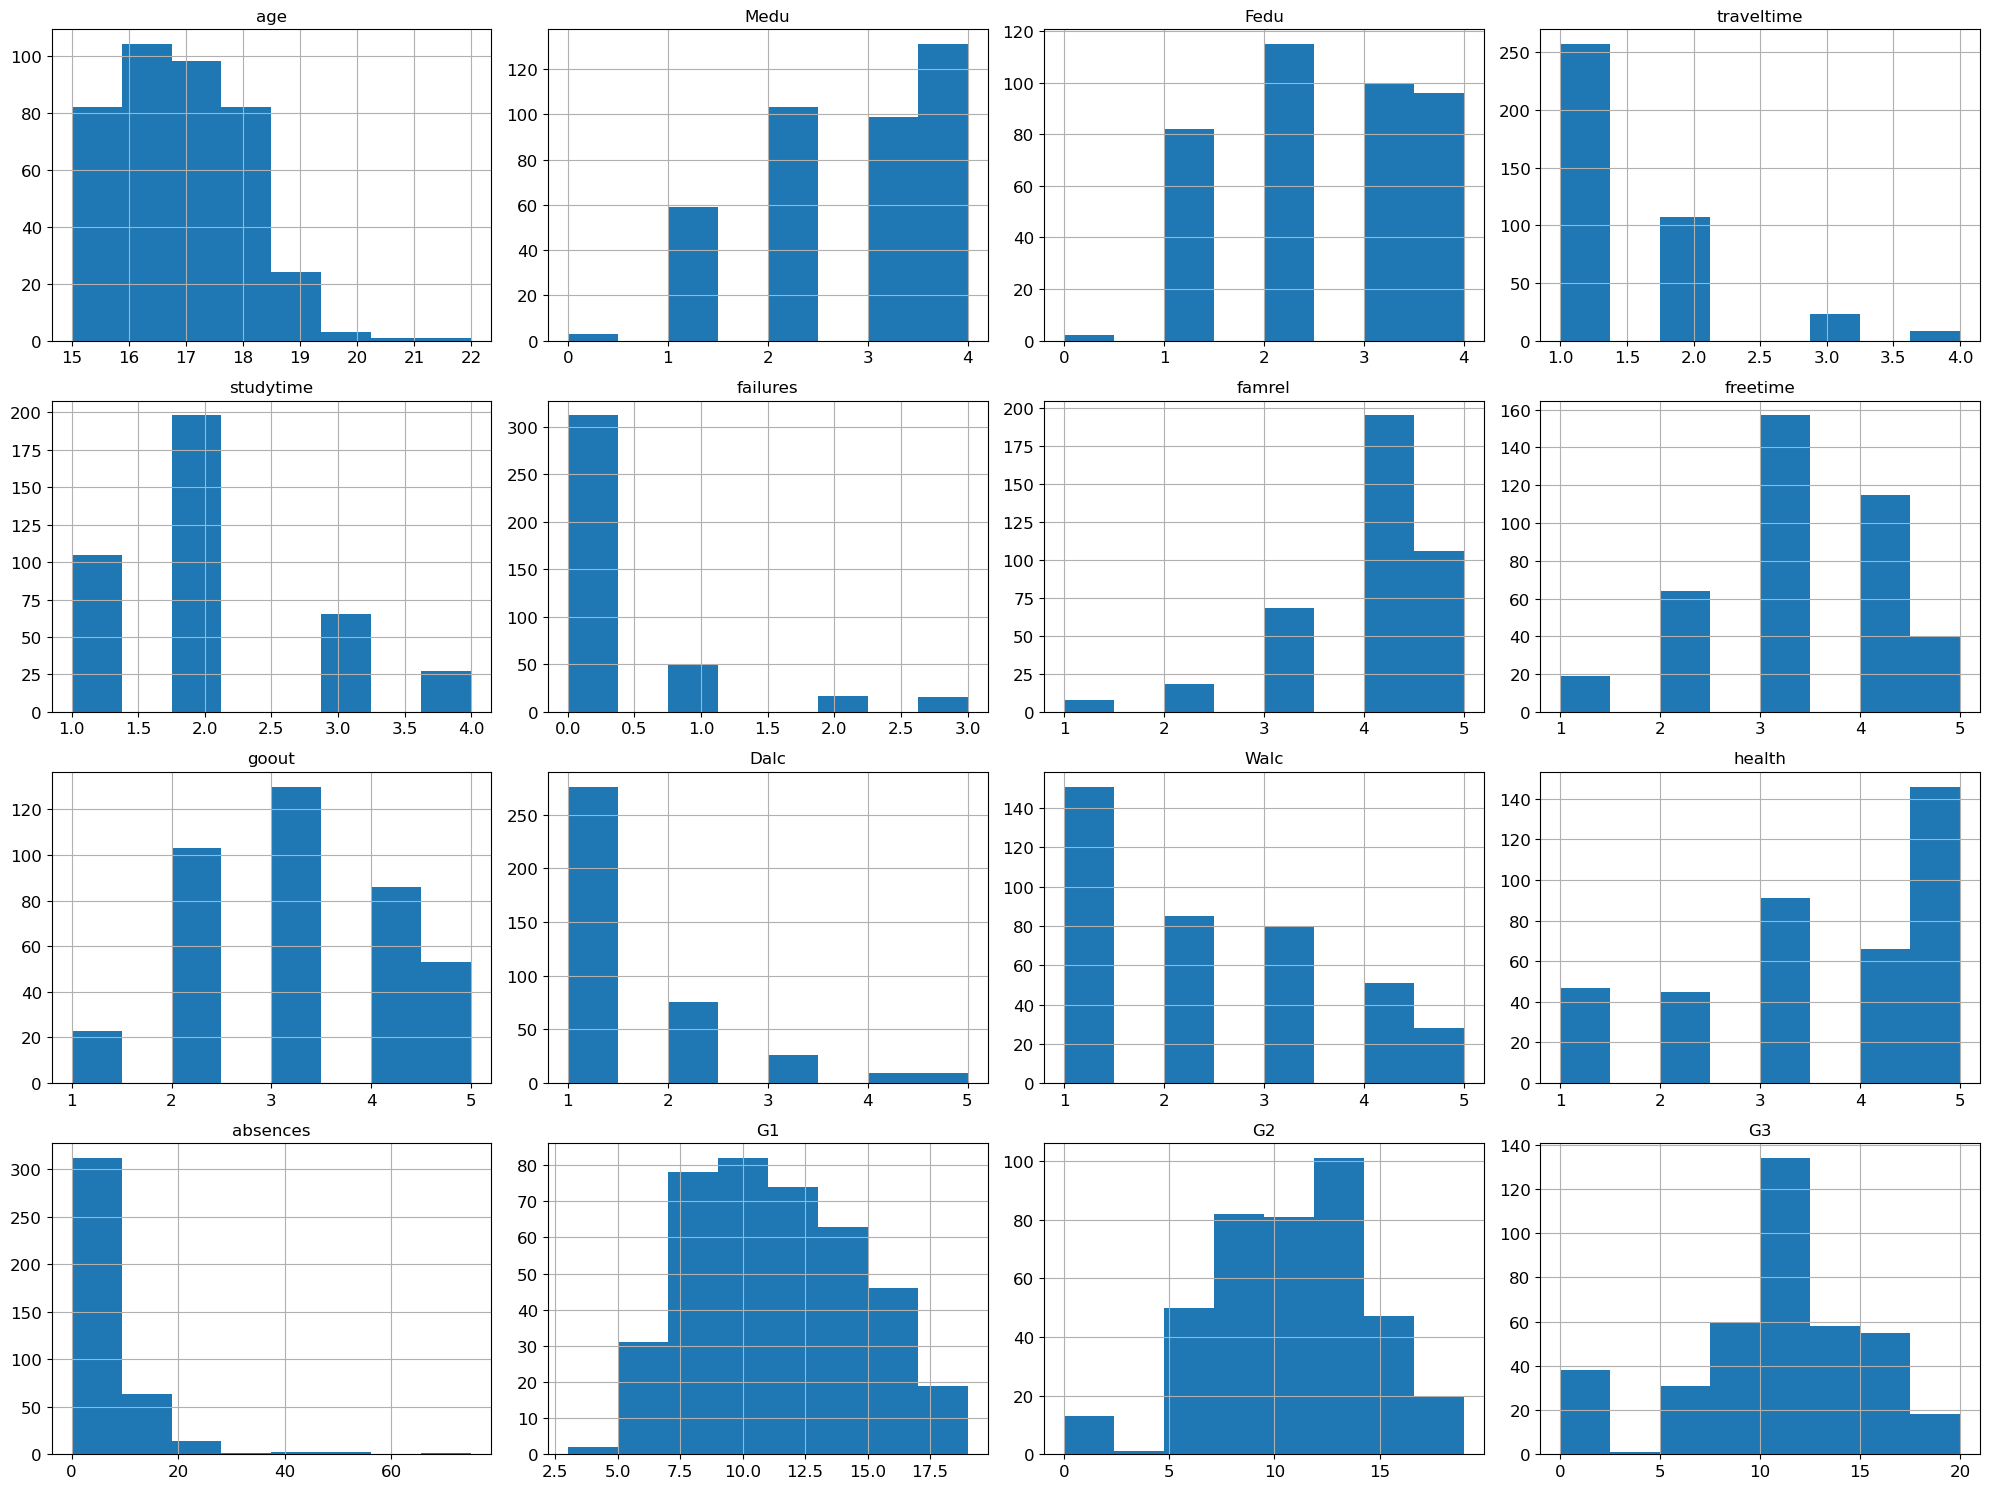

In [9]:
stud_perform.hist(bins=8, figsize=(20, 15))
save_fig("num_dat_distribution")
plt.show()

In [10]:
stud_perform.duplicated().sum()

np.int64(0)

Saving figure absence_distribution


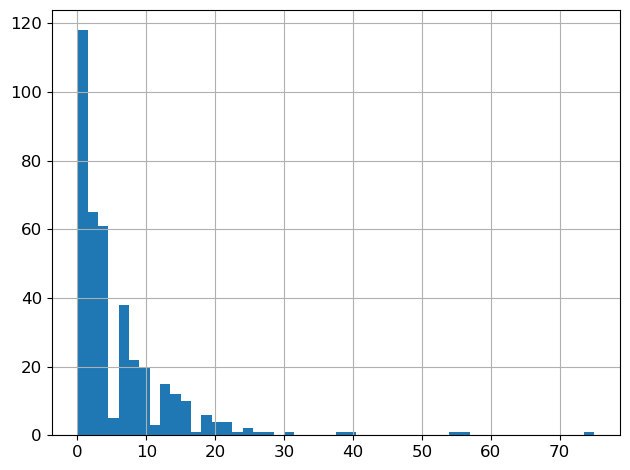

In [11]:
stud_perform.absences.hist(bins=50)
save_fig("absence_distribution")
plt.show()

The absences variable contains several extreme values compared to the majority of observations. However, these values likely represent genuine student behavior rather than measurement errors. Since the dataset is relatively small and tree-based models are not highly sensitive to outliers, the values were retained without modification.


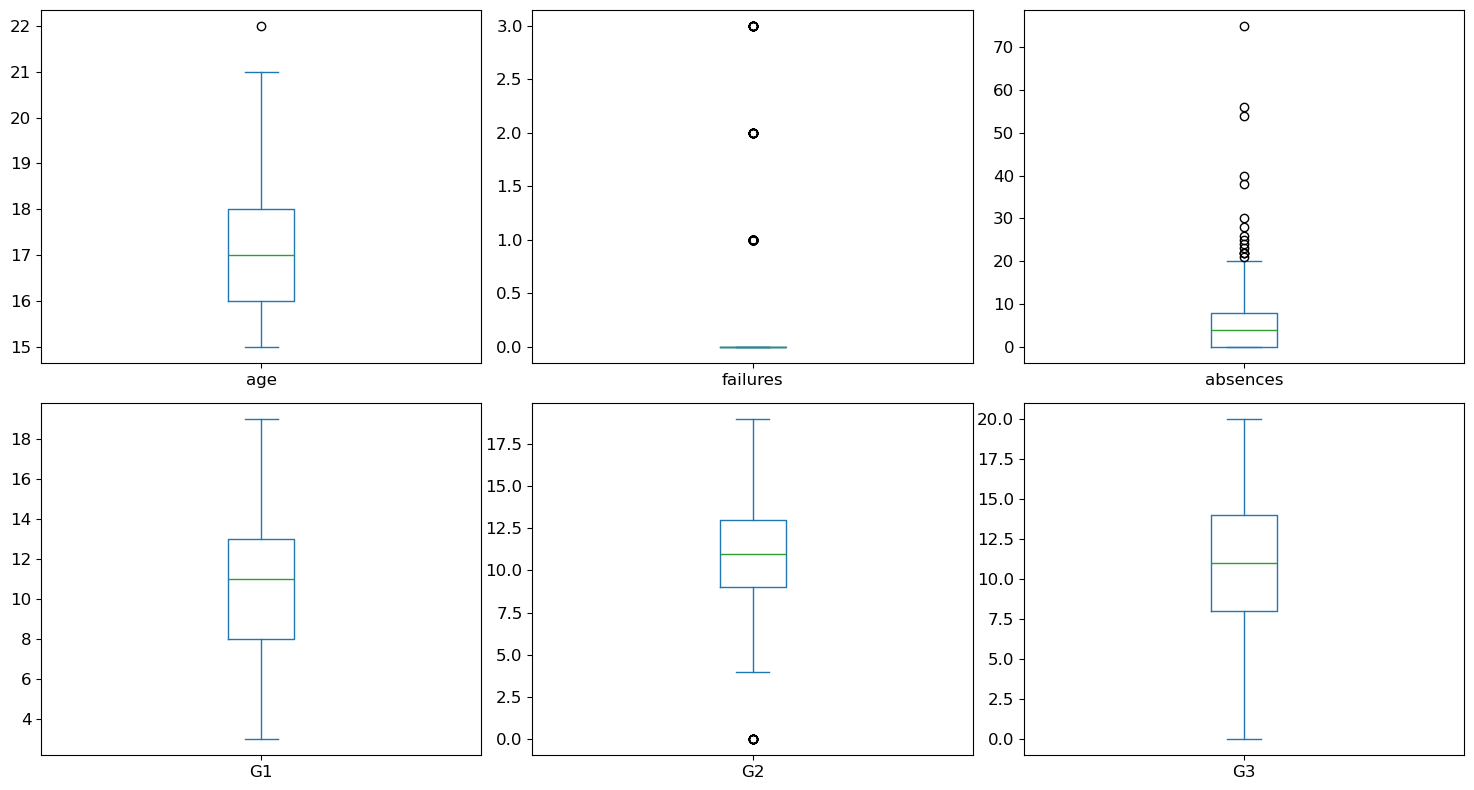

In [12]:
cols = ["age", "failures", "absences", "G1", "G2", "G3"]

stud_perform[cols].plot(kind="box", subplots=True, layout=(2, 3), figsize=(15, 8))

plt.tight_layout()
plt.show()

In [13]:
stud_perform.failures.value_counts()

failures
0    312
1     50
2     17
3     16
Name: count, dtype: int64

Saving figure age_distribution


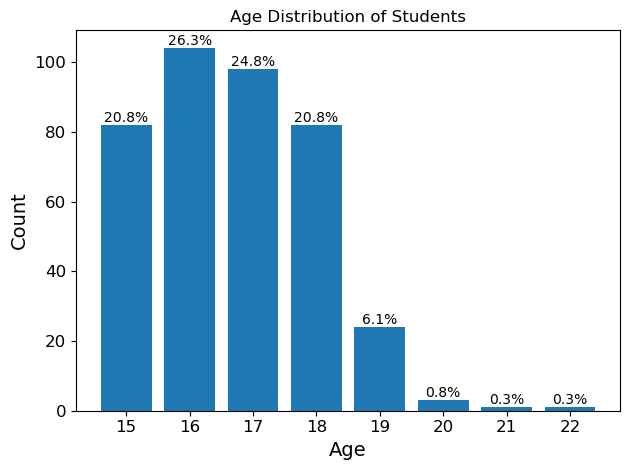

In [14]:
ages = stud_perform["age"].value_counts().sort_index()

sizes = np.array((ages / ages.sum()) * 100)

bars = plt.bar(ages.index, ages.values)

plt.bar_label(bars, labels=[f"{s:.1f}%" for s in sizes])

plt.title("Age Distribution of Students")
plt.xlabel("Age")
plt.ylabel("Count")

save_fig("age_distribution")
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_25812\3171343694.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=stud_perform, x="studytime", y="G3", palette="rainbow")


Saving figure final_grade_vs_study_time


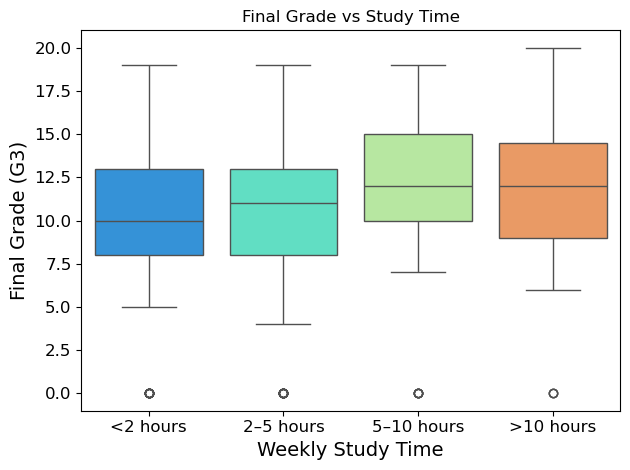

In [15]:
sns.boxplot(data=stud_perform, x="studytime", y="G3", palette="rainbow")

plt.title("Final Grade vs Study Time")
plt.xlabel("Weekly Study Time")
plt.ylabel("Final Grade (G3)")

plt.xticks([0, 1, 2, 3], ["<2 hours", "2–5 hours", "5–10 hours", ">10 hours"])

save_fig("final_grade_vs_study_time")
plt.show()

Students who study **less than 2 hours per week** tend to have the **lowest average final grades (G3)**. This suggests that limited study time may negatively affect academic performance.

In contrast, students who study **more than 10 hours per week** generally achieve **higher grades**, indicating that increased study time is associated with better academic outcomes. However, only a small proportion of students fall into this category.


Saving figure corr_matrix


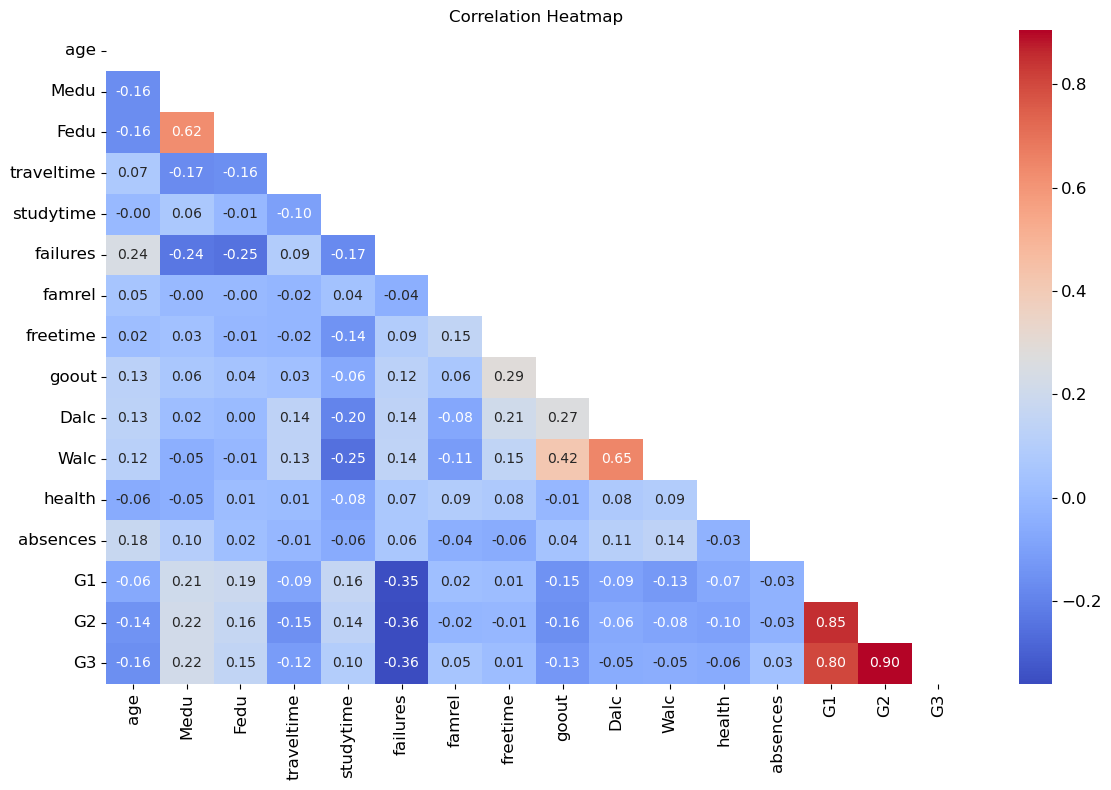

In [16]:
corr_matrix = stud_perform.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 8))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

save_fig("corr_matrix")
plt.show()

#### Key Insights from the Correlation Heatmap

- **Strong correlation between grades:**  
  The variables **G1, G2, and G3** are highly correlated. In particular, **G2 shows the strongest correlation with the final grade (G3 ≈ 0.90)**, indicating that previous academic performance is the strongest predictor of final results.

- **Past failures negatively affect performance:**  
  The variable **failures** has a moderate negative correlation with grades (≈ -0.36), suggesting that students with more past failures tend to achieve lower final grades.

- **Study time has a weak positive relationship with grades:**  
  The correlation between **studytime and G3 (≈ 0.10)** is relatively small, indicating that while studying more may help, it is not the dominant factor affecting performance.

- **Alcohol consumption patterns:**  
  **Weekday and weekend alcohol consumption (Dalc and Walc)** are moderately correlated (≈ 0.65), meaning students who drink during weekdays are also likely to drink more on weekends.

- **Parental education relationship:**  
  **Mother's and father's education levels** show a moderate correlation (≈ 0.62), suggesting that parents often have similar education levels.

- **Age and academic failures:**  
  A positive correlation between **age and failures (≈ 0.24)** suggests that older students in the dataset are slightly more likely to have experienced past academic failures.


In [17]:
cat_columns.columns

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='str')

1. Data cleaning
2. Encoding categorical variables
3. Feature engineering (optional small additions)
4. Correlation analysis
5. Feature selection
6. Train ML models


In [18]:
stud_perform["avg_alcohol"] = (stud_perform["Dalc"] + stud_perform["Walc"]) / 2
stud_perform["avg_parent_edu"] = (stud_perform["Medu"] + stud_perform["Fedu"]) / 2

stud_perform.select_dtypes(include=["number"]).corr()[
    [
        "Dalc",
        "Walc",
        "avg_alcohol",
        "Medu",
        "Fedu",
        "avg_parent_edu",
    ]
]

,Dalc,Walc,avg_alcohol,Medu,Fedu,avg_parent_edu
age,0.131125,0.117276,0.134972,-0.163658,-0.163438,-0.181527
Medu,0.019834,-0.047123,-0.021681,1.000000,0.623455,0.901584
Fedu,0.002386,-0.012631,-0.007127,0.623455,1.000000,0.900333
traveltime,0.138325,0.134116,0.149134,-0.171639,-0.158194,-0.183068
studytime,-0.196019,-0.253785,-0.252698,0.064944,-0.009175,0.031073
failures,0.136047,0.141962,0.153203,-0.236680,-0.250408,-0.270293
famrel,-0.077594,-0.113397,-0.108427,-0.003914,-0.001370,-0.002937
freetime,0.209001,0.147822,0.189754,0.030891,-0.012846,0.010087
goout,0.266994,0.420386,0.392683,0.064094,0.043105,0.059526
Dalc,1.000000,0.647544,0.869140,0.019834,0.002386,0.012361


#### Interpretation of Engineered Features

Two new features were created to summarize related variables:

- **avg_alcohol** from `Dalc` and `Walc`
- **avg_parent_edu** from `Medu` and `Fedu`

The correlation matrix shows that **avg_alcohol** has a very strong correlation with both `Dalc` (0.87) and `Walc` (0.94). This indicates that the new feature effectively represents overall alcohol consumption behavior while reducing two variables into one.

Similarly, **avg_parent_edu** shows strong correlations with `Medu` (0.90) and `Fedu` (0.90), suggesting that it captures the combined educational background of the parents.

Additionally, the correlations between these engineered features and the target variable (`G3`) remain similar to the original variables, meaning that important predictive information is preserved.

Therefore, replacing the four original features (`Dalc`, `Walc`, `Medu`, `Fedu`) with the two engineered features (`avg_alcohol`, `avg_parent_edu`) reduces feature redundancy while maintaining the underlying relationships in the dataset.


In [19]:
stud_perform = stud_perform.drop(["Dalc", "Walc", "Medu", "Fedu"], axis=1)

In [20]:
one_hot_encoded = pd.get_dummies(
    stud_perform, columns=cat_columns.columns, drop_first=True, dtype=float
)
one_hot_encoded

,age,traveltime,studytime,failures,famrel,freetime,goout,health,absences,G1,G2,G3,avg_alcohol,avg_parent_edu,school_MS,sex_M,address_U,famsize_LE3,Pstatus_T,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,2,2,0,4,3,4,3,6,5,6,6,1.0,4.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,17,1,2,0,5,3,3,3,4,5,5,6,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
2,15,1,2,3,4,3,2,3,10,7,8,10,2.5,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0
3,15,1,3,0,3,2,2,5,2,15,14,15,1.0,3.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,16,1,2,0,4,3,2,5,4,6,10,10,1.5,3.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,20,1,2,2,5,5,4,4,11,9,9,9,4.5,2.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0
391,17,2,1,0,2,4,5,2,3,14,16,16,3.5,2.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
392,21,1,1,3,5,5,3,3,3,10,8,7,3.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
393,18,3,1,0,4,4,1,5,0,11,12,10,3.5,2.5,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [21]:
corr_matrix = stud_perform.corr(numeric_only=True)
corr_matrix["G3"].sort_values(ascending=False)

G3                1.000000
G2                0.904868
G1                0.801468
avg_parent_edu    0.205224
studytime         0.097820
famrel            0.051363
absences          0.034247
freetime          0.011307
avg_alcohol      -0.058245
health           -0.061335
traveltime       -0.117142
goout            -0.132791
age              -0.161579
failures         -0.360415
Name: G3, dtype: float64

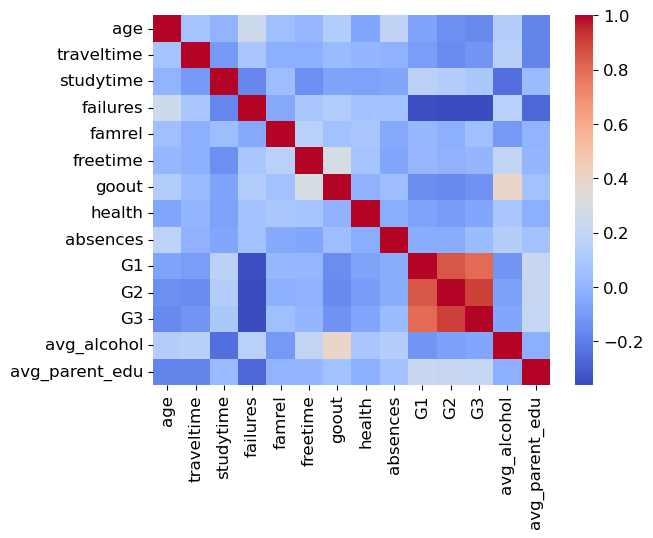

In [22]:
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.show()

In [23]:
bins = [0, 10, 12, 14, 16, 20]
labels = ["F", "D", "C", "B", "A"]

one_hot_encoded["G3_grade"] = pd.cut(
    one_hot_encoded["G3"], bins=bins, labels=labels, include_lowest=True
)

In [24]:
selector = VarianceThreshold(threshold=0.01)

X = one_hot_encoded.drop(columns=["G3", "G3_grade"])
y = one_hot_encoded.G3_grade

X_var = selector.fit_transform(X)

In [25]:
selected_features = X.columns[selector.get_support()]

print(selected_features)
len(selected_features) == len(one_hot_encoded.columns) - 2

Index(['age', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime',
       'goout', 'health', 'absences', 'G1', 'G2', 'avg_alcohol',
       'avg_parent_edu', 'school_MS', 'sex_M', 'address_U', 'famsize_LE3',
       'Pstatus_T', 'Mjob_health', 'Mjob_other', 'Mjob_services',
       'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services',
       'Fjob_teacher', 'reason_home', 'reason_other', 'reason_reputation',
       'guardian_mother', 'guardian_other', 'schoolsup_yes', 'famsup_yes',
       'paid_yes', 'activities_yes', 'nursery_yes', 'higher_yes',
       'internet_yes', 'romantic_yes'],
      dtype='str')


True

In [26]:
model = DecisionTreeClassifier(random_state=42)

rfe = RFE(model, n_features_to_select=20)
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_rfe = rfe.fit_transform(X_scaled, y)

In [27]:
selected_features = X.columns[rfe.support_]

print(selected_features)

Index(['age', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime',
       'goout', 'health', 'absences', 'G1', 'G2', 'avg_alcohol',
       'avg_parent_edu', 'Mjob_other', 'Mjob_services', 'Mjob_teacher',
       'reason_home', 'reason_reputation', 'famsup_yes', 'internet_yes'],
      dtype='str')


In [28]:
ranking = pd.DataFrame({"Feature": X.columns, "Rank": rfe.ranking_}).sort_values("Rank")

print(ranking)

              Feature  Rank
0                 age     1
1          traveltime     1
2           studytime     1
3            failures     1
4              famrel     1
5            freetime     1
6               goout     1
7              health     1
8            absences     1
9                  G1     1
10                 G2     1
11        avg_alcohol     1
12     avg_parent_edu     1
21       Mjob_teacher     1
20      Mjob_services     1
19         Mjob_other     1
28  reason_reputation     1
26        reason_home     1
37       internet_yes     1
32         famsup_yes     1
35        nursery_yes     2
22        Fjob_health     3
23         Fjob_other     4
24      Fjob_services     5
31      schoolsup_yes     6
38       romantic_yes     7
29    guardian_mother     8
27       reason_other     9
36         higher_yes    10
33           paid_yes    11
25       Fjob_teacher    12
34     activities_yes    13
15          address_U    14
30     guardian_other    15
14              sex_

In [29]:
model = DecisionTreeRegressor(random_state=42)

rfe = RFE(model, n_features_to_select=20)
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
y = one_hot_encoded.G3

X_rfe = rfe.fit_transform(X_scaled, y)

In [30]:
X.columns[rfe.support_]

Index(['age', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'health',
       'absences', 'G1', 'G2', 'avg_alcohol', 'avg_parent_edu', 'school_MS',
       'address_U', 'Mjob_other', 'Fjob_health', 'Fjob_other',
       'reason_reputation', 'guardian_other', 'nursery_yes'],
      dtype='str')

In [31]:
ranking = pd.DataFrame({"Feature": X.columns, "Rank": rfe.ranking_}).sort_values("Rank")

print(ranking)

              Feature  Rank
0                 age     1
2           studytime     1
3            failures     1
4              famrel     1
6               goout     1
5            freetime     1
7              health     1
8            absences     1
12     avg_parent_edu     1
9                  G1     1
10                 G2     1
11        avg_alcohol     1
15          address_U     1
13          school_MS     1
23         Fjob_other     1
19         Mjob_other     1
28  reason_reputation     1
30     guardian_other     1
22        Fjob_health     1
35        nursery_yes     1
16        famsize_LE3     2
1          traveltime     3
24      Fjob_services     4
27       reason_other     5
34     activities_yes     6
33           paid_yes     7
25       Fjob_teacher     8
26        reason_home     9
36         higher_yes    10
31      schoolsup_yes    11
32         famsup_yes    12
14              sex_M    13
29    guardian_mother    14
37       internet_yes    15
20      Mjob_service

Feature selection using Recursive Feature Elimination (RFE) with Decision Tree models shows that academic performance indicators such as G1, G2, failures, studytime, and absences are the most important predictors of the final grade (G3).

Engineered features such as avg_alcohol and avg_parent_edu were also selected, indicating that overall alcohol consumption and parental education contribute some predictive information.

Demographic variables such as sex, school, and family status appear less important compared to academic and behavioral factors. Overall, the results suggest that previous academic performance is the strongest determinant of final student grades.

**Academic history > lifestyle factors > demographic factors**


### Interpretation of the Dataset & EDA

Based on the exploratory data analysis, here is an interpretation of the dataset:

- **Strong Predictors**: Previous grades (`G1`, `G2`) are the strongest predictors of the final grade (`G3`). However, depending on the business objective, using them might cause **data leakage** if the goal is to predict performance early in the course before these grades are available.
- **Academic & Behavioral Factors**: Past failures, study time, and absences show meaningful relationships with the final grade. High absences and failures correlate with lower grades, while more study time is linked to higher grades.
- **Engineered Features**: Combining related features like alcohol consumption (`Dalc` + `Walc`) and parental education (`Medu` + `Fedu`) successfully captures the underlying patterns while effectively reducing dimensionality and potential multicollinearity.
- **Demographics**: Out of the numerous demographic factors (school, sex, family status), they appear to have a less significant direct impact on final grades compared to academic history and behavioral habits.
- **Outliers**: There are extreme values in `absences`, but your decision to keep them is sound as they reflect genuine student behavior, and tree-based algorithms are robust to such outliers.


### Proposed Data Preprocessing Pipeline

To build a robust and effective machine learning model, the following preprocessing steps should be included in your pipeline (using `sklearn.compose.ColumnTransformer` and `sklearn.pipeline.Pipeline`):

1. **Feature Selection (Preventing Data Leakage)**:
   - _Action_: Drop `G1` and `G2` if the goal is to predict final grades at the start of the term. If predicting late-term, keep them. Also, drop the original target `G3` if predicting the binned `G3_grade`.
   - _Reason_: Using `G1/G2` can dominate the model and prevent it from learning underlying demographic/behavioral patterns.

2. **Custom Feature Engineering Transformer**:
   - _Action_: Create a custom transformer to automatically create `avg_alcohol` and `avg_parent_edu` and drop the original corresponding features.
   - _Reason_: Ensures any new test data gets the exact same feature engineering seamlessly without manual intervention.

3. **Handling Categorical Variables**:
   - _Action_: Apply `OneHotEncoder(drop='first')` for nominal categorical variables.
   - _Reason_: Machine learning models require numerical input. Dropping the first category prevents the dummy variable trap (perfect multicollinearity).

4. **Scaling Numerical Variables**:
   - _Action_: Apply `StandardScaler` or `MinMaxScaler` to numerical features (like `age`, `absences`, `avg_alcohol`).
   - _Reason_: Essential for distance-based algorithms like SVM and KNN, and regularized models like Logistic Regression. It ensures features with larger ranges (like `absences`) don't disproportionately outweigh features with smaller ranges.


## Preprocessing Pipeline


In [32]:
DATASET_PATH = os.path.join(PROJECT_ROOT_DIR, "Datasets", "student-mat.csv")

stud_perform = pd.read_csv(DATASET_PATH, sep=";")

In [33]:
X = stud_perform.drop(columns=["G3"])

bins = [0, 8, 12, 16, 20]
labels = ["D", "C", "B", "A"]

y = pd.cut(stud_perform["G3"], bins=bins, labels=labels, include_lowest=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.23, random_state=42, stratify=y
)

### Custom Transformers


In [34]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin


def drop_g1_g2(X):
    return X.drop(columns=["G1", "G2"], errors="ignore")


drop_grade_columns = FunctionTransformer(drop_g1_g2)


class CombinedAttribsTransformer(BaseEstimator, TransformerMixin):

    VALID_MODES = {"avg", "sum", None}

    def __init__(self, alcohol_mode=None, parent_edu_mode=None):
        self.alcohol_mode = alcohol_mode
        self.parent_edu_mode = parent_edu_mode

    def fit(self, X, y=None):

        if self.alcohol_mode not in self.VALID_MODES:
            raise ValueError(
                f"alcohol_mode must be one of {self.VALID_MODES}, got {self.alcohol_mode}"
            )
        if self.parent_edu_mode not in self.VALID_MODES:
            raise ValueError(
                f"parent_edu_mode must be one of {self.VALID_MODES}, got {self.parent_edu_mode}"
            )

        return self

    def transform(self, X):
        X = X.copy()

        if self.alcohol_mode and {"Dalc", "Walc"}.issubset(X.columns):

            if self.alcohol_mode == "avg":
                X["avg_alcohol"] = (X["Dalc"] + X["Walc"]) / 2
            else:
                X["sum_alcohol"] = X["Dalc"] + X["Walc"]
            X = X.drop(columns=["Dalc", "Walc"])

        if self.parent_edu_mode and {"Fedu", "Medu"}.issubset(X.columns):

            if self.parent_edu_mode == "avg":
                X["avg_parent_edu"] = (X["Fedu"] + X["Medu"]) / 2
            else:
                X["sum_parent_edu"] = X["Fedu"] + X["Medu"]
            X = X.drop(columns=["Fedu", "Medu"])

        return X

In [35]:
from sklearn.compose import ColumnTransformer, make_column_selector

column_preprocessor = ColumnTransformer(
    [
        (
            "categorical_encoder",
            OneHotEncoder(handle_unknown="ignore"),
            make_column_selector(dtype_exclude=np.number),
        ),
        (
            "continuous_scaler",
            StandardScaler(),
            ["age", "absences"],
        ),
    ],
    remainder="passthrough",
)


preprocessing_pipeline = Pipeline(
    [
        ("drop_grade_columns", drop_grade_columns),
        (
            "feature_engineer",
            CombinedAttribsTransformer(),
        ),
        ("column_preprocessing", column_preprocessor),
    ]
)

In [36]:
X_prepared = preprocessing_pipeline.fit_transform(X_train)
X_prepared

array([[1., 0., 1., ..., 2., 2., 4.],
       [1., 0., 1., ..., 3., 3., 1.],
       [1., 0., 1., ..., 2., 3., 4.],
       ...,
       [1., 0., 1., ..., 1., 1., 3.],
       [1., 0., 1., ..., 1., 2., 4.],
       [1., 0., 0., ..., 1., 2., 4.]], shape=(304, 56))

## Select and Train the Model


In [37]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_predict

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "SVC": SVC(
        probability=True, random_state=42
    ),  # probability=True so we can compute log_loss & ROC AUC
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
}


def evaluate_model(X_prepared, y, model, model_name):
    y_pred = cross_val_predict(model, X_prepared, y, cv=5, method="predict")

    # classification report
    creport = classification_report(y, y_pred)
    print(creport)

    # confusion matrix
    cm = confusion_matrix(y, y_pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["A", "B", "C", "D"]
    ).plot(cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

==================LogisticRegression==================
              precision    recall  f1-score   support

           A       0.24      0.22      0.23        18
           B       0.34      0.35      0.35        82
           C       0.41      0.43      0.42       125
           D       0.33      0.29      0.31        79

    accuracy                           0.36       304
   macro avg       0.33      0.32      0.33       304
weighted avg       0.36      0.36      0.36       304



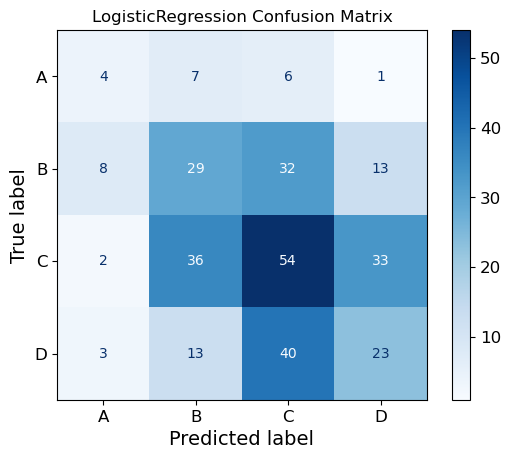

==================SVC==================
              precision    recall  f1-score   support

           A       0.00      0.00      0.00        18
           B       0.28      0.09      0.13        82
           C       0.44      0.91      0.59       125
           D       0.78      0.18      0.29        79

    accuracy                           0.44       304
   macro avg       0.37      0.29      0.25       304
weighted avg       0.46      0.44      0.35       304



c:\Users\USER\.conda\envs\ml-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\.conda\envs\ml-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\.conda\envs\ml-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


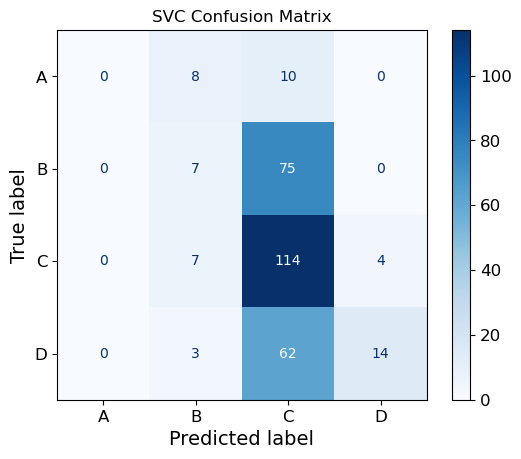

==================KNN==================
              precision    recall  f1-score   support

           A       0.15      0.11      0.13        18
           B       0.32      0.38      0.34        82
           C       0.46      0.57      0.51       125
           D       0.38      0.19      0.25        79

    accuracy                           0.39       304
   macro avg       0.33      0.31      0.31       304
weighted avg       0.38      0.39      0.38       304



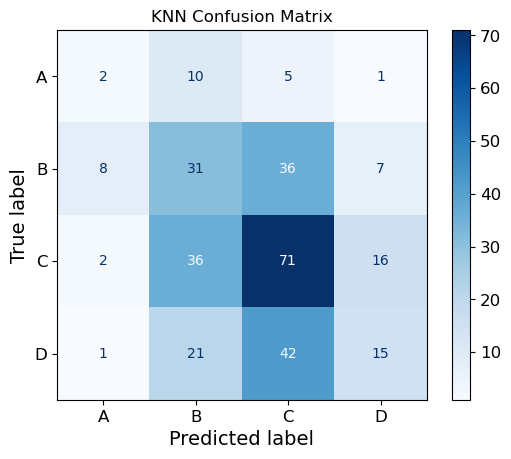

==================DecisionTree==================
              precision    recall  f1-score   support

           A       0.08      0.06      0.07        18
           B       0.35      0.35      0.35        82
           C       0.45      0.43      0.44       125
           D       0.38      0.43      0.40        79

    accuracy                           0.39       304
   macro avg       0.32      0.32      0.32       304
weighted avg       0.38      0.39      0.39       304



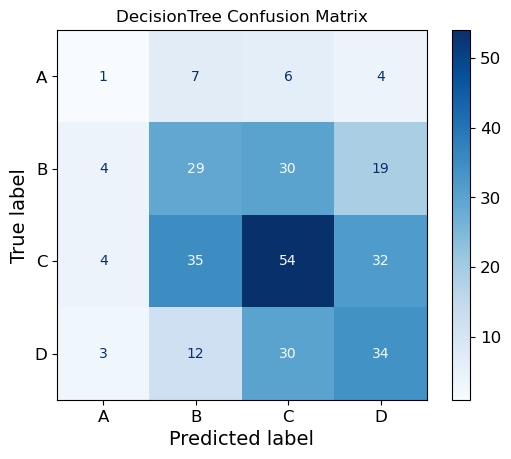

In [38]:
for name, model in models.items():
    print(f"=================={name}==================")
    evaluate_model(X_prepared, y_train, model, name)

In [39]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from scipy.stats import randint, loguniform
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

full_pipeline = Pipeline(
    [
        ("preprocess", preprocessing_pipeline),
        ("clf", DecisionTreeClassifier(random_state=42)),
    ]
)


param_distributions = {
    "preprocess__feature_engineer__alcohol_mode": ["avg", "sum", None],
    "preprocess__feature_engineer__parent_edu_mode": ["avg", "sum", None],
    "clf__max_depth": [None] + list(range(3, 21)),
    "clf__min_samples_leaf": randint(1, 11),
    "clf__min_samples_split": randint(2, 21),
    "clf__criterion": ["gini", "entropy"],
    "clf__splitter": ["best", "random"],
    "clf__max_features": [None, "sqrt", "log2"],
    "clf__ccp_alpha": loguniform(1e-6, 1e-2),
    "clf__class_weight": ["balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
random_search = RandomizedSearchCV(
    estimator=full_pipeline,
    param_distributions=param_distributions,
    n_iter=120,
    scoring="f1_macro",
    n_jobs=-1,
    cv=cv,
    verbose=2,
    random_state=42,
    return_train_score=False,
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 120 candidates, totalling 600 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'clf__ccp_alpha': <scipy.stats....001D5F9159FD0>, 'clf__class_weight': ['balanced'], 'clf__criterion': ['gini', 'entropy'], 'clf__max_depth': [None, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",120
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation

In [40]:
print("BEST PARAMS")
print(random_search.best_params_)
print("BEST CV (macro F1):", random_search.best_score_)


res = pd.DataFrame(random_search.cv_results_)
res_sorted = res.sort_values("rank_test_score").head(10)
display(res_sorted[["rank_test_score", "mean_test_score", "params"]])

BEST PARAMS
{'clf__ccp_alpha': np.float64(1.0079572416607791e-05), 'clf__class_weight': 'balanced', 'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__max_features': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__splitter': 'best', 'preprocess__feature_engineer__alcohol_mode': 'sum', 'preprocess__feature_engineer__parent_edu_mode': 'sum'}
BEST CV (macro F1): 0.32201424206910484


,rank_test_score,mean_test_score,params
46,1,0.322014,"{'clf__ccp_alpha': 1.0079572416607791e-05, 'cl..."
26,2,0.320366,"{'clf__ccp_alpha': 4.982711200081135e-06, 'clf..."
89,3,0.314238,"{'clf__ccp_alpha': 0.0006175473960166775, 'clf..."
77,4,0.313029,"{'clf__ccp_alpha': 0.001289463742227575, 'clf_..."
9,5,0.311815,"{'clf__ccp_alpha': 1.329652145729951e-05, 'clf..."
113,6,0.311809,"{'clf__ccp_alpha': 0.003968896568985892, 'clf_..."
4,7,0.311474,"{'clf__ccp_alpha': 0.0027527173929429417, 'clf..."
100,8,0.310704,"{'clf__ccp_alpha': 3.2740891740248485e-05, 'cl..."
14,9,0.310194,"{'clf__ccp_alpha': 0.0006960678239135191, 'clf..."
13,10,0.309198,"{'clf__ccp_alpha': 0.007706343825607382, 'clf_..."


In [41]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "preprocess__feature_engineer__alcohol_mode": [None, "avg"],
    "preprocess__feature_engineer__parent_edu_mode": ["avg", None],
    "clf__max_depth": [8, 10, 11, 12, 15],
    "clf__min_samples_leaf": [3, 4, 5, 6, 8],
    "clf__min_samples_split": [6, 8, 10, 12, 15],
    "clf__criterion": ["gini", "entropy"],
    "clf__splitter": ["best", "random"],
    "clf__max_features": [None, "sqrt", "log2"],
    "clf__ccp_alpha": [1e-06, 8e-06, 3e-05, 1e-04, 5e-04],
    "clf__class_weight": ["balanced"],
}

grid = GridSearchCV(
    estimator=full_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    return_train_score=False,
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 30000 candidates, totalling 150000 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__ccp_alpha': [1e-06, 8e-06, ...], 'clf__class_weight': ['balanced'], 'clf__criterion': ['gini', 'entropy'], 'clf__max_depth': [8, 10, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more me

In [42]:
print("BEST PARAMS (grid):")
print(grid.best_params_)
print("BEST CV (macro F1):", grid.best_score_)

res = pd.DataFrame(grid.cv_results_)
res = res.sort_values("rank_test_score").head(10)
display(res[["rank_test_score", "mean_test_score", "std_test_score", "params"]])

BEST PARAMS (grid):
{'clf__ccp_alpha': 1e-06, 'clf__class_weight': 'balanced', 'clf__criterion': 'entropy', 'clf__max_depth': 8, 'clf__max_features': None, 'clf__min_samples_leaf': 6, 'clf__min_samples_split': 6, 'clf__splitter': 'best', 'preprocess__feature_engineer__alcohol_mode': None, 'preprocess__feature_engineer__parent_edu_mode': 'avg'}
BEST CV (macro F1): 0.35661020242023184


,rank_test_score,mean_test_score,std_test_score,params
27120,1,0.35661,0.053373,"{'clf__ccp_alpha': 0.0005, 'clf__class_weight'..."
27128,1,0.35661,0.053373,"{'clf__ccp_alpha': 0.0005, 'clf__class_weight'..."
27136,1,0.35661,0.053373,"{'clf__ccp_alpha': 0.0005, 'clf__class_weight'..."
15120,1,0.35661,0.053373,"{'clf__ccp_alpha': 3e-05, 'clf__class_weight':..."
15128,1,0.35661,0.053373,"{'clf__ccp_alpha': 3e-05, 'clf__class_weight':..."
3136,1,0.35661,0.053373,"{'clf__ccp_alpha': 1e-06, 'clf__class_weight':..."
3128,1,0.35661,0.053373,"{'clf__ccp_alpha': 1e-06, 'clf__class_weight':..."
21136,1,0.35661,0.053373,"{'clf__ccp_alpha': 0.0001, 'clf__class_weight'..."
21144,1,0.35661,0.053373,"{'clf__ccp_alpha': 0.0001, 'clf__class_weight'..."
21120,1,0.35661,0.053373,"{'clf__ccp_alpha': 0.0001, 'clf__class_weight'..."


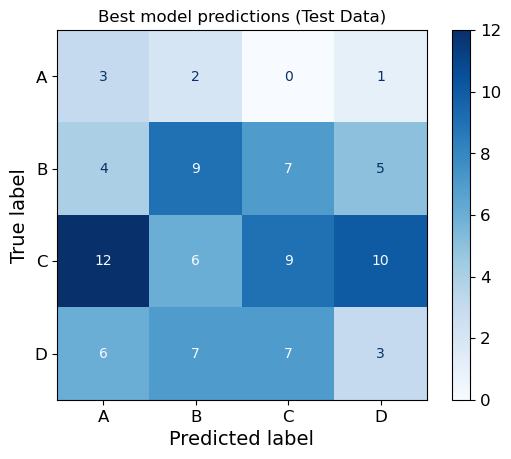

              precision    recall  f1-score   support

           A       0.12      0.50      0.19         6
           B       0.38      0.36      0.37        25
           C       0.39      0.24      0.30        37
           D       0.16      0.13      0.14        23

    accuracy                           0.26        91
   macro avg       0.26      0.31      0.25        91
weighted avg       0.31      0.26      0.27        91



In [43]:
y_test_pred = grid.best_estimator_.predict(X_test)
cm_test = confusion_matrix(y_test, y_test_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm_test, display_labels=["A", "B", "C", "D"]
).plot(cmap="Blues")

plt.title("Best model predictions (Test Data)")
plt.show()

print(classification_report(y_test, y_test_pred))

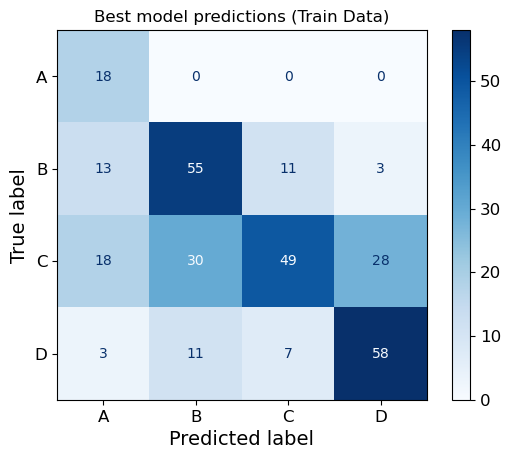

              precision    recall  f1-score   support

           A       0.35      1.00      0.51        18
           B       0.57      0.67      0.62        82
           C       0.73      0.39      0.51       125
           D       0.65      0.73      0.69        79

    accuracy                           0.59       304
   macro avg       0.58      0.70      0.58       304
weighted avg       0.65      0.59      0.59       304



In [44]:
y_train_pred = grid.best_estimator_.predict(X_train)
cm_train = confusion_matrix(y_train, y_train_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm_train, display_labels=["A", "B", "C", "D"]
).plot(cmap="Blues")

plt.title("Best model predictions (Train Data)")
plt.show()

print(classification_report(y_train, y_train_pred))

From the model confusion matrix it is clear that the model performs well on training set and performs very badly on test set with accuracy for training set as 59% and for test is 26%. This proves that the modell is **overfitting**.
For this we have to follow some reugularization techniques.


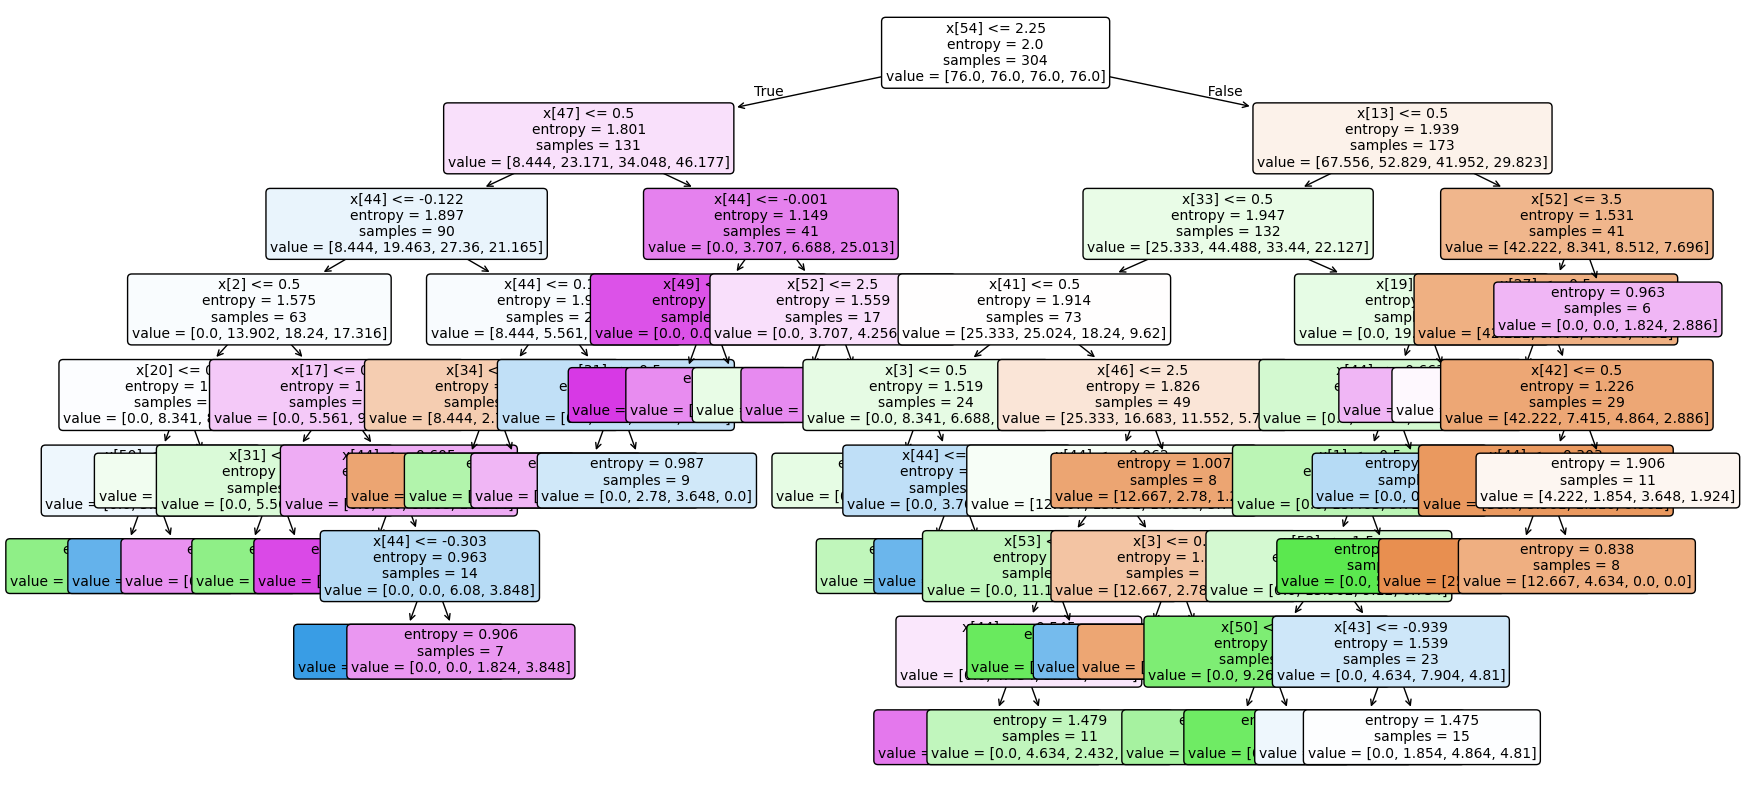

In [45]:
from sklearn.tree import plot_tree

best_model = grid.best_estimator_.named_steps["clf"]

plt.figure(figsize=(20, 10))
plot_tree(best_model, filled=True, rounded=True, fontsize=10)
plt.show()

In [46]:
best_preprocessor = grid.best_estimator_.named_steps["preprocess"]
X_train_prepared = best_preprocessor.fit_transform(X_train)
X_test_prepared = best_preprocessor.transform(X_test)

path = best_model.cost_complexity_pruning_path(X_train_prepared, y_train)
ccp_alphas = path.ccp_alphas
ccp_alphas

array([0.        , 0.00377193, 0.00844402, 0.00981447, 0.01096343,
       0.01244859, 0.01273411, 0.01455149, 0.01497568, 0.0150901 ,
       0.01513829, 0.01671847, 0.01727944, 0.01828063, 0.01930913,
       0.0194703 , 0.0194791 , 0.01958359, 0.01982039, 0.02197816,
       0.02576183, 0.02728758, 0.03077091, 0.03092883, 0.03238976,
       0.03566327, 0.04836424, 0.04996131, 0.05180826, 0.06810568,
       0.08630808, 0.11180577])

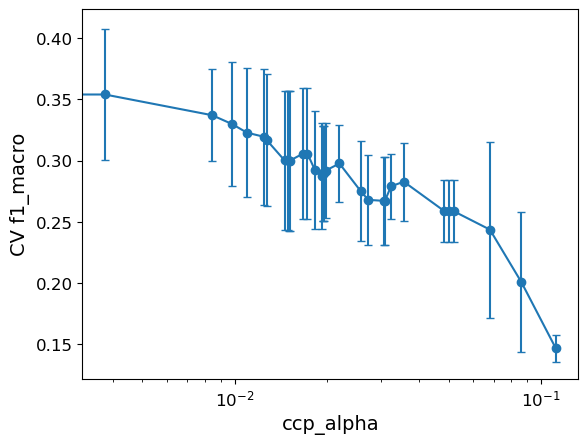

In [47]:
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_params = {
    k.replace("clf__", ""): v
    for k, v in grid.best_params_.items()
    if "clf__" in k and k != "clf__ccp_alpha"
}

cv_means = []
cv_stds = []

for alpha in ccp_alphas:
    tree = DecisionTreeClassifier(**base_params, ccp_alpha=alpha, random_state=42)
    scores = cross_val_score(tree, X_train_prepared, y_train, cv=cv, scoring="f1_macro")
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

plt.errorbar(ccp_alphas, cv_means, yerr=cv_stds, marker="o", capsize=3)
plt.xscale("log")
plt.xlabel("ccp_alpha")
plt.ylabel("CV f1_macro")
plt.show()

In [48]:
best_idx = np.argmax(cv_means)
best_mean = cv_means[best_idx]
best_std = cv_stds[best_idx]

threshold = best_mean - best_std
candidate_indicies = np.where(cv_means >= threshold)[0]
best_alpha = ccp_alphas[candidate_indicies].max()
best_alpha

np.float64(0.017279437426294814)

In [49]:
grid.best_estimator_.named_steps["clf"].ccp_alpha
np.float64(0.010745084329180431)

np.float64(0.010745084329180431)

In [50]:
tree_best_alpha = DecisionTreeClassifier(
    **{
        k.replace("clf__", ""): v
        for k, v in grid.best_params_.items()
        if "clf__" in k and k != "clf__ccp_alpha"
    },
    ccp_alpha=best_alpha,
    random_state=42
)
tree_best_alpha.fit(X_train_prepared, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",6
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

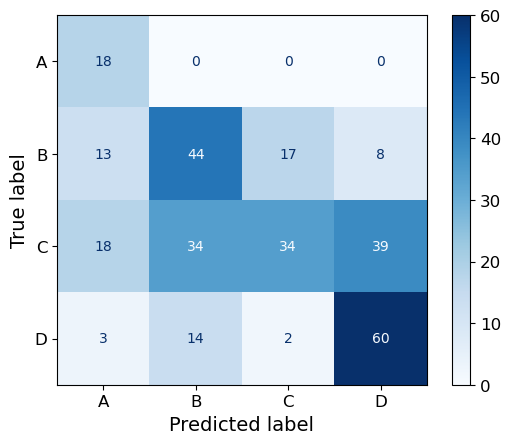

              precision    recall  f1-score   support

           A       0.35      1.00      0.51        18
           B       0.48      0.54      0.51        82
           C       0.64      0.27      0.38       125
           D       0.56      0.76      0.65        79

    accuracy                           0.51       304
   macro avg       0.51      0.64      0.51       304
weighted avg       0.56      0.51      0.49       304



In [51]:
y_train_pred_alpha = tree_best_alpha.predict(X_train_prepared)

cm_alpha = confusion_matrix(y_train, y_train_pred_alpha)
ConfusionMatrixDisplay(
    confusion_matrix=cm_alpha, display_labels=["A", "B", "C", "D"]
).plot(cmap="Blues")
plt.show()
print(classification_report(y_train, y_train_pred_alpha))

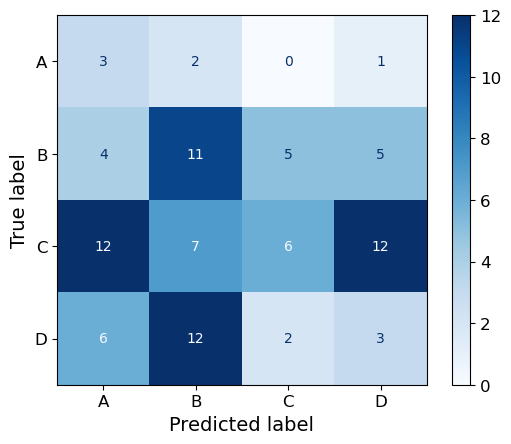

              precision    recall  f1-score   support

           A       0.12      0.50      0.19         6
           B       0.34      0.44      0.39        25
           C       0.46      0.16      0.24        37
           D       0.14      0.13      0.14        23

    accuracy                           0.25        91
   macro avg       0.27      0.31      0.24        91
weighted avg       0.33      0.25      0.25        91



In [52]:
y_test_pred_alpha = tree_best_alpha.predict(X_test_prepared)

cm_alpha = confusion_matrix(y_test, y_test_pred_alpha)
ConfusionMatrixDisplay(
    confusion_matrix=cm_alpha, display_labels=["A", "B", "C", "D"]
).plot(cmap="Blues")
plt.show()
print(classification_report(y_test, y_test_pred_alpha))

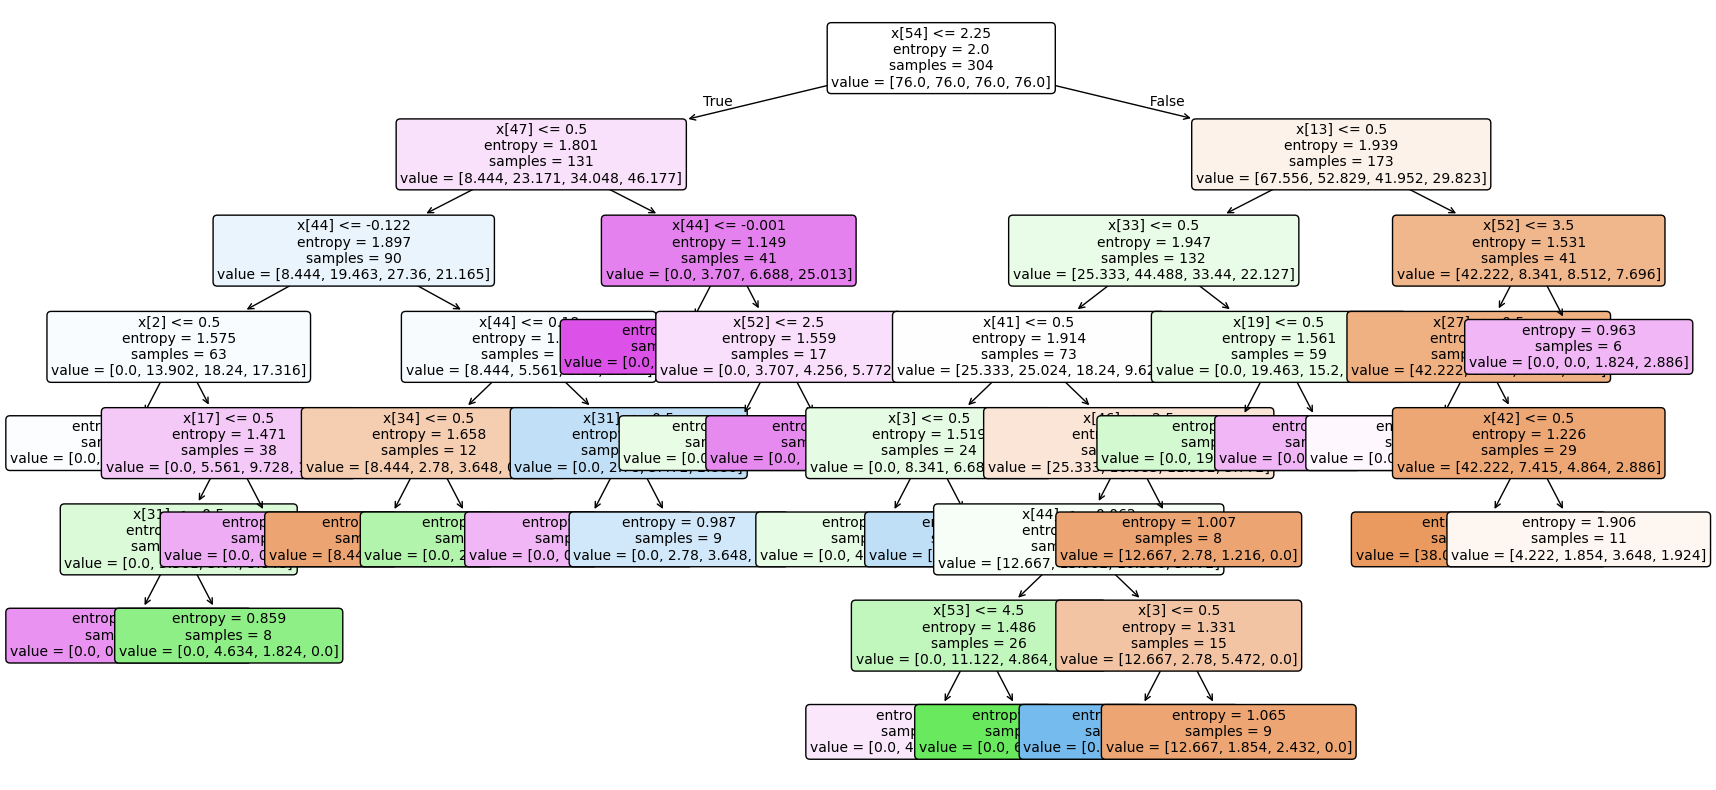

In [53]:
plt.figure(figsize=(20, 10))
plot_tree(tree_best_alpha, filled=True, rounded=True, fontsize=10)
plt.show()

### Compute Feature importance


In [54]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    tree_best_alpha,
    X_test_prepared,
    y_test,
    scoring="f1_macro",
    random_state=42,
    n_repeats=20,
)

feature_names = best_preprocessor.named_steps[
    "column_preprocessing"
].get_feature_names_out()

importance = pd.Series(perm.importances_mean, index=feature_names).sort_values(
    ascending=False
)

print(importance)

categorical_encoder__romantic_no          0.022194
categorical_encoder__sex_M                0.019869
categorical_encoder__activities_yes       0.010030
categorical_encoder__Mjob_services        0.007599
continuous_scaler__absences               0.004939
remainder__Walc                           0.004381
remainder__health                         0.003435
categorical_encoder__Fjob_at_home         0.000000
categorical_encoder__famsize_LE3          0.000000
categorical_encoder__Pstatus_T            0.000000
categorical_encoder__Pstatus_A            0.000000
categorical_encoder__Mjob_at_home         0.000000
categorical_encoder__Mjob_health          0.000000
categorical_encoder__Mjob_other           0.000000
categorical_encoder__Mjob_teacher         0.000000
categorical_encoder__reason_other         0.000000
categorical_encoder__Fjob_health          0.000000
categorical_encoder__Fjob_services        0.000000
categorical_encoder__school_MS            0.000000
categorical_encoder__address_U 

In [ ]:
columns_to_keep = [
    "romantic",
    "sex",
    "activities",
    "Mjob",
    "absences",
    "Walc",
    "Dalc",
    "health",
    "Fedu",
    "Medu",
    "activities",
    "studytime",
    "paid",
    "Fjob",
    "schoolsup",
    "failures",
]

all(col in list(stud_perform.columns) for col in columns_to_drop)

True

In [69]:
columns_to_drop = list(stud_perform.columns.difference(columns_to_keep))
columns_to_drop

['G1',
 'G2',
 'G3',
 'Pstatus',
 'address',
 'age',
 'famrel',
 'famsize',
 'famsup',
 'freetime',
 'goout',
 'guardian',
 'higher',
 'internet',
 'nursery',
 'reason',
 'school',
 'traveltime']

## Retune with eliminated columns


In [70]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin


def drop_columns(X):
    return X.drop(
        columns=[
            "Fjob",
            "G1",
            "G2",
            "Pstatus",
            "famsup",
            "freetime",
            "guardian",
            "higher",
            "nursery",
            "paid",
            "romantic",
            "school",
            "traveltime",
        ],
        errors="ignore",
    )


drop_grade_columns = FunctionTransformer(drop_columns)


class CombinedAttribsTransformer(BaseEstimator, TransformerMixin):

    VALID_MODES = {"avg", "sum", None}

    def __init__(self, alcohol_mode=None, parent_edu_mode=None):
        self.alcohol_mode = alcohol_mode
        self.parent_edu_mode = parent_edu_mode

    def fit(self, X, y=None):

        if self.alcohol_mode not in self.VALID_MODES:
            raise ValueError(
                f"alcohol_mode must be one of {self.VALID_MODES}, got {self.alcohol_mode}"
            )
        if self.parent_edu_mode not in self.VALID_MODES:
            raise ValueError(
                f"parent_edu_mode must be one of {self.VALID_MODES}, got {self.parent_edu_mode}"
            )

        return self

    def transform(self, X):
        X = X.copy()

        if self.alcohol_mode and {"Dalc", "Walc"}.issubset(X.columns):

            if self.alcohol_mode == "avg":
                X["avg_alcohol"] = (X["Dalc"] + X["Walc"]) / 2
            else:
                X["sum_alcohol"] = X["Dalc"] + X["Walc"]
            X = X.drop(columns=["Dalc", "Walc"])

        if self.parent_edu_mode and {"Fedu", "Medu"}.issubset(X.columns):

            if self.parent_edu_mode == "avg":
                X["avg_parent_edu"] = (X["Fedu"] + X["Medu"]) / 2
            else:
                X["sum_parent_edu"] = X["Fedu"] + X["Medu"]
            X = X.drop(columns=["Fedu", "Medu"])

        elif {"Fedu"}.issubset(X.columns):
            X = X.drop(columns=["Fedu"])

        return X

In [71]:
from sklearn.compose import ColumnTransformer, make_column_selector

column_preprocessor = ColumnTransformer(
    [
        (
            "categorical_encoder",
            OneHotEncoder(handle_unknown="ignore"),
            make_column_selector(dtype_exclude=np.number),
        ),
        (
            "continuous_scaler",
            StandardScaler(),
            ["age"],
        ),
    ],
    remainder="passthrough",
)


preprocessing_pipeline = Pipeline(
    [
        ("drop_grade_columns", drop_grade_columns),
        (
            "feature_engineer",
            CombinedAttribsTransformer(),
        ),
        ("column_preprocessing", column_preprocessor),
    ]
)

full_pipeline = Pipeline(
    [
        ("preprocess", preprocessing_pipeline),
        ("clf", DecisionTreeClassifier(random_state=42)),
    ]
)

X_prepared = preprocessing_pipeline.fit_transform(X_train)

In [72]:
model_eval_dropColumns = DecisionTreeClassifier(
    **{
        k.replace("clf__", ""): v
        for k, v in grid.best_params_.items()
        if "clf__" in k and k != "clf__ccp_alpha"
    },
    ccp_alpha=best_alpha,
    random_state=42
)

model_eval_dropColumns.fit(X_prepared, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",6
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [73]:
def evaluate_model(X_prepared, y, model, model_name):
    y_pred = model.predict(X_prepared)

    # classification report
    creport = classification_report(y, y_pred)
    print(creport)

    # confusion matrix
    cm = confusion_matrix(y, y_pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["A", "B", "C", "D"]
    ).plot(cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

              precision    recall  f1-score   support

           A       0.31      1.00      0.47        18
           B       0.49      0.45      0.47        82
           C       0.64      0.38      0.48       125
           D       0.52      0.62      0.57        79

    accuracy                           0.50       304
   macro avg       0.49      0.61      0.50       304
weighted avg       0.55      0.50      0.50       304



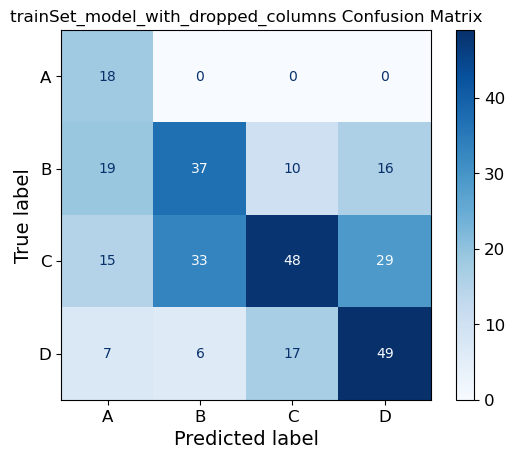

In [74]:
evaluate_model(
    X_prepared, y_train, model_eval_dropColumns, "trainSet_model_with_dropped_columns"
)

              precision    recall  f1-score   support

           A       0.15      0.67      0.24         6
           B       0.32      0.24      0.27        25
           C       0.37      0.27      0.31        37
           D       0.33      0.26      0.29        23

    accuracy                           0.29        91
   macro avg       0.29      0.36      0.28        91
weighted avg       0.33      0.29      0.29        91



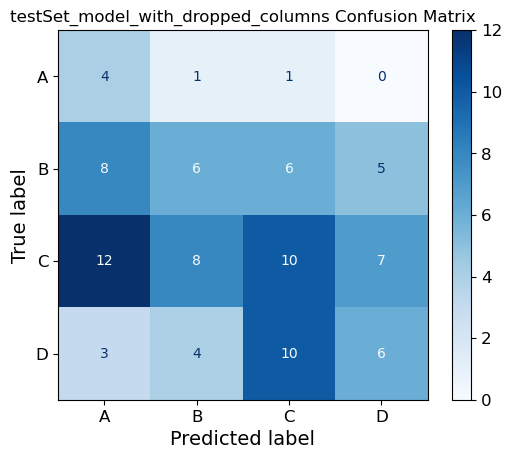

In [75]:
X_test_prepared = preprocessing_pipeline.transform(X_test)
evaluate_model(
    X_test_prepared,
    y_test,
    model_eval_dropColumns,
    "testSet_model_with_dropped_columns",
)

In [78]:
param_distributions = {
    "preprocess__feature_engineer__alcohol_mode": ["avg", "sum", None],
    "preprocess__feature_engineer__parent_edu_mode": ["avg", "sum", None],
    "clf__max_depth": [None] + list(range(3, 21)),
    "clf__min_samples_leaf": randint(1, 11),
    "clf__min_samples_split": randint(2, 21),
    "clf__criterion": ["gini", "entropy"],
    "clf__splitter": ["best", "random"],
    "clf__max_features": [None, "sqrt", "log2"],
    "clf__ccp_alpha": loguniform(1e-6, 1e-2),
    "clf__class_weight": ["balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
random_search = RandomizedSearchCV(
    estimator=full_pipeline,
    param_distributions=param_distributions,
    n_iter=240,
    scoring="f1_macro",
    n_jobs=-1,
    cv=cv,
    verbose=2,
    random_state=42,
    return_train_score=False,
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'clf__ccp_alpha': <scipy.stats....001D5F6BF8550>, 'clf__class_weight': ['balanced'], 'clf__criterion': ['gini', 'entropy'], 'clf__max_depth': [None, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",240
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation

In [79]:
print("BEST PARAMS")
print(random_search.best_params_)
print("BEST CV (macro F1):", random_search.best_score_)


res = pd.DataFrame(random_search.cv_results_)
res_sorted = res.sort_values("rank_test_score").head(10)
display(res_sorted[["rank_test_score", "mean_test_score", "params"]])

BEST PARAMS
{'clf__ccp_alpha': np.float64(0.00443960303729181), 'clf__class_weight': 'balanced', 'clf__criterion': 'entropy', 'clf__max_depth': 4, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 9, 'clf__min_samples_split': 15, 'clf__splitter': 'best', 'preprocess__feature_engineer__alcohol_mode': 'avg', 'preprocess__feature_engineer__parent_edu_mode': 'sum'}
BEST CV (macro F1): 0.38522963161195306


,rank_test_score,mean_test_score,params
192,1,0.385230,"{'clf__ccp_alpha': 0.00443960303729181, 'clf__..."
157,2,0.359188,"{'clf__ccp_alpha': 1.5019717035559225e-06, 'cl..."
198,3,0.354391,"{'clf__ccp_alpha': 1.9425795337877237e-05, 'cl..."
139,4,0.353485,"{'clf__ccp_alpha': 0.00021486528009914135, 'cl..."
236,5,0.352938,"{'clf__ccp_alpha': 3.977597437883501e-05, 'clf..."
196,6,0.352038,"{'clf__ccp_alpha': 2.628577061511284e-06, 'clf..."
197,7,0.350931,"{'clf__ccp_alpha': 0.00011771900253242054, 'cl..."
152,8,0.344845,"{'clf__ccp_alpha': 2.5477724935338494e-05, 'cl..."
193,9,0.341871,"{'clf__ccp_alpha': 0.0005524095129928633, 'clf..."
223,10,0.341825,"{'clf__ccp_alpha': 0.00019161918406231346, 'cl..."


In [ ]:
import os

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "preprocess__feature_engineer__alcohol_mode": [None, "avg"],
    "preprocess__feature_engineer__parent_edu_mode": ["sum", "avg", None],
    "clf__max_depth": [3, 4, 5, 6, 8, 10, 15],
    "clf__min_samples_leaf": [4, 6, 8, 9, 11, 14],
    "clf__min_samples_split": [6, 8, 10, 12, 15, 18, 22],
    "clf__criterion": ["entropy", "gini"],
    "clf__splitter": ["best", "random"],
    "clf__max_features": ["sqrt", "log2", None],
    "clf__ccp_alpha": [1e-4, 5e-4, 1e-3, 2e-3, 4.43960303729181e-3, 8e-3, best_alpha],
    "clf__class_weight": ["balanced"],
}

grid = GridSearchCV(
    estimator=full_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=os.cpu_count() - 1,
    verbose=2,
    return_train_score=False,
    refit=True,
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 148176 candidates, totalling 740880 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__ccp_alpha': [0.0001, 0.0005, ...], 'clf__class_weight': ['balanced'], 'clf__criterion': ['entropy', 'gini'], 'clf__max_depth': [3, 4, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",15
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more m

In [84]:
def evaluate_pipeline(X, y, pipeline, pipeline_name):
    y_pred = pipeline.predict(X)

    # classification report
    creport = classification_report(y, y_pred)
    print(creport)

    # confusion matrix
    cm = confusion_matrix(y, y_pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["A", "B", "C", "D"]
    ).plot(cmap="Blues")
    plt.title(f"{pipeline_name} Confusion Matrix")
    plt.show()

              precision    recall  f1-score   support

           A       0.24      0.56      0.34        18
           B       0.36      0.59      0.45        82
           C       0.50      0.36      0.42       125
           D       0.63      0.33      0.43        79

    accuracy                           0.42       304
   macro avg       0.44      0.46      0.41       304
weighted avg       0.48      0.42      0.43       304



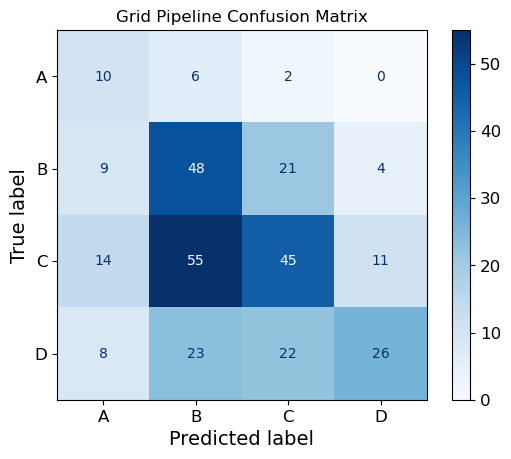

In [86]:
grid_pipeline = grid.best_estimator_

evaluate_pipeline(X_train, y_train, grid_pipeline, "Grid Pipeline")

              precision    recall  f1-score   support

           A       0.12      0.50      0.19         6
           B       0.32      0.52      0.39        25
           C       0.44      0.22      0.29        37
           D       0.14      0.04      0.07        23

    accuracy                           0.27        91
   macro avg       0.26      0.32      0.24        91
weighted avg       0.31      0.27      0.26        91



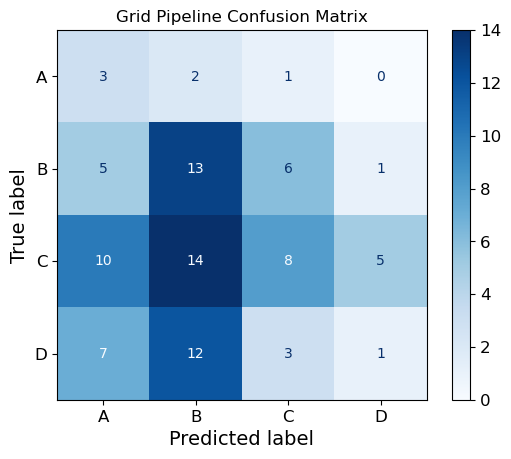

In [87]:
evaluate_pipeline(X_test, y_test, grid_pipeline, "Grid Pipeline")

In [88]:
import pandas as pd
from sklearn.inspection import permutation_importance


def compute_permutation_importance(
    model,
    X_test,
    y_test,
    preprocessor,
    scoring="f1_macro",
    random_state=42,
    n_repeats=20,
):

    perm = permutation_importance(
        model,
        X_test,
        y_test,
        scoring=scoring,
        random_state=random_state,
        n_repeats=n_repeats,
    )

    feature_names = preprocessor.named_steps[
        "column_preprocessing"
    ].get_feature_names_out()
    importance = pd.Series(perm.importances_mean, index=feature_names).sort_values(
        ascending=False
    )
    return importance

In [97]:
preprocessor = grid.best_estimator_.named_steps["preprocess"]
model = grid.best_estimator_.named_steps["clf"]
X_test_prepared = preprocessor.transform(X_train)

# importance = compute_permutation_importance(
#     model,
#     X_test_prepared,
#     y_test,
#     preprocessor
# )

# print(importance)
X_test_prepared

array([[1. , 0. , 1. , ..., 8. , 2. , 8. ],
       [1. , 0. , 0. , ..., 2. , 3. , 2. ],
       [1. , 0. , 1. , ..., 6. , 2.5, 8. ],
       ...,
       [1. , 0. , 0. , ..., 0. , 1. , 2. ],
       [1. , 0. , 0. , ..., 0. , 1.5, 4. ],
       [0. , 1. , 0. , ..., 8. , 1.5, 3. ]], shape=(304, 30))